# Shopify Stock Visualization, Time-Series Analysis & Financial Insights

This notebook uses the Shopify stock dataset to visualize prices, study moving averages, examine daily returns, and create a simple financial summary.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('shopify_stock.csv')
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


## 3. Prepare the Data

In [3]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

price_columns = ['open', 'high', 'low', 'close', 'volume']
for column in price_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df = df.dropna(subset=price_columns).copy()
df.head()

/tmp/ipykernel_566/872139748.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'])


,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB


## 4. Create Daily Returns

In [5]:
df['daily_return'] = df['close'].pct_change()
df[['date', 'close', 'daily_return']].head()

,date,close,daily_return
0,2015-05-21 00:00:00-04:00,2.568,NaN
1,2015-05-22 00:00:00-04:00,2.831,0.102414
2,2015-05-26 00:00:00-04:00,2.965,0.047333
3,2015-05-27 00:00:00-04:00,2.750,-0.072513
4,2015-05-28 00:00:00-04:00,2.745,-0.001818


## 5. OHLC Prices Over Time

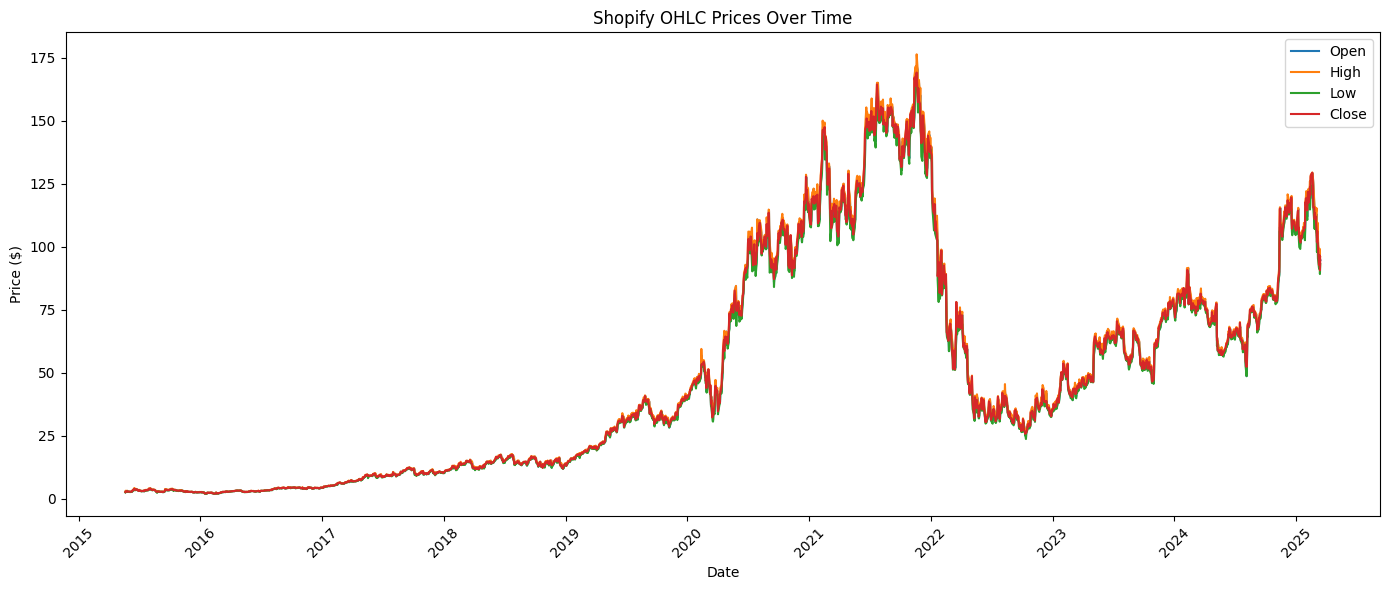

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(df['date'], df['open'], label='Open')
plt.plot(df['date'], df['high'], label='High')
plt.plot(df['date'], df['low'], label='Low')
plt.plot(df['date'], df['close'], label='Close')

plt.title('Shopify OHLC Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Trading Volume Over Time

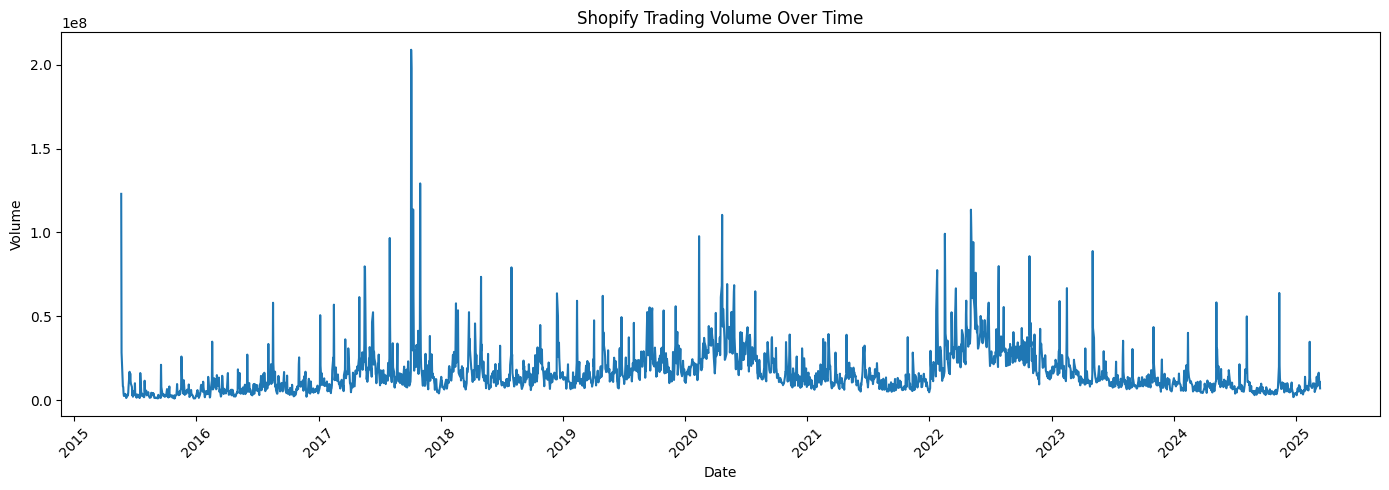

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['volume'])
plt.title('Shopify Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. 20-Day and 50-Day Moving Averages

In [8]:
df['MA20'] = df['close'].rolling(window=20).mean()
df['MA50'] = df['close'].rolling(window=50).mean()

df[['date', 'close', 'MA20', 'MA50']].tail()

,date,close,MA20,MA50
2464,2025-03-10 00:00:00-04:00,92.750000,114.415001,111.7678
2465,2025-03-11 00:00:00-04:00,92.949997,113.067500,111.4232
2466,2025-03-12 00:00:00-04:00,96.529999,111.714500,111.1546
2467,2025-03-13 00:00:00-04:00,90.589996,110.219500,110.8028
2468,2025-03-14 00:00:00-04:00,94.849998,108.579500,110.5660


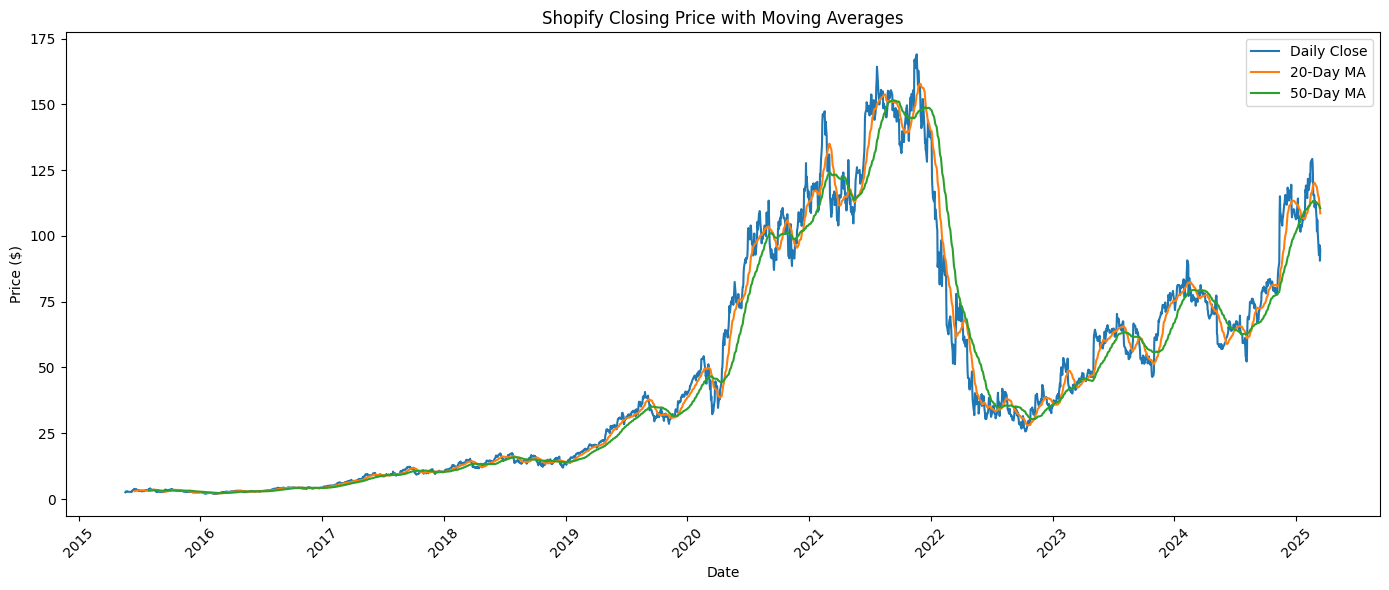

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(df['date'], df['close'], label='Daily Close')
plt.plot(df['date'], df['MA20'], label='20-Day MA')
plt.plot(df['date'], df['MA50'], label='50-Day MA')

plt.title('Shopify Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Daily Returns

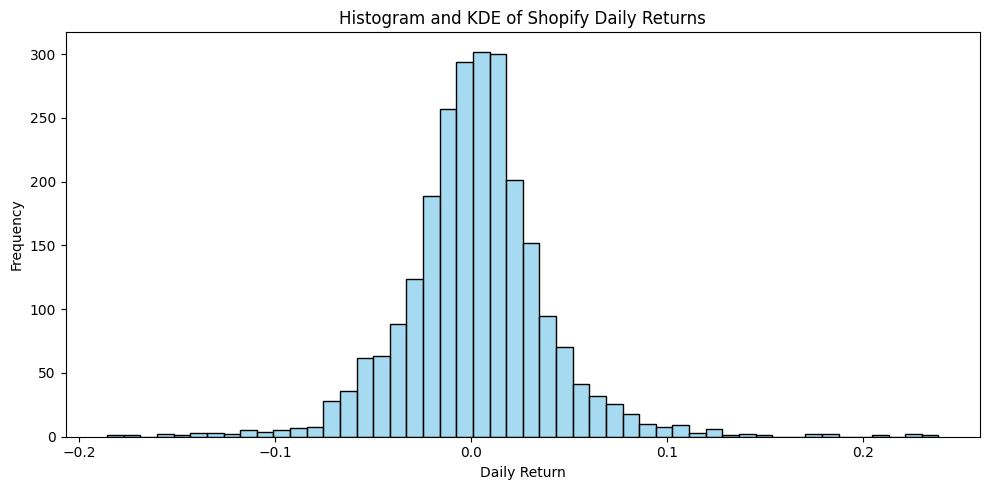

In [10]:
returns = df['daily_return'].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(returns, bins=50, kde=False, color='skyblue')
plt.title('Histogram and KDE of Shopify Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 9. KDE Plot for Daily Returns

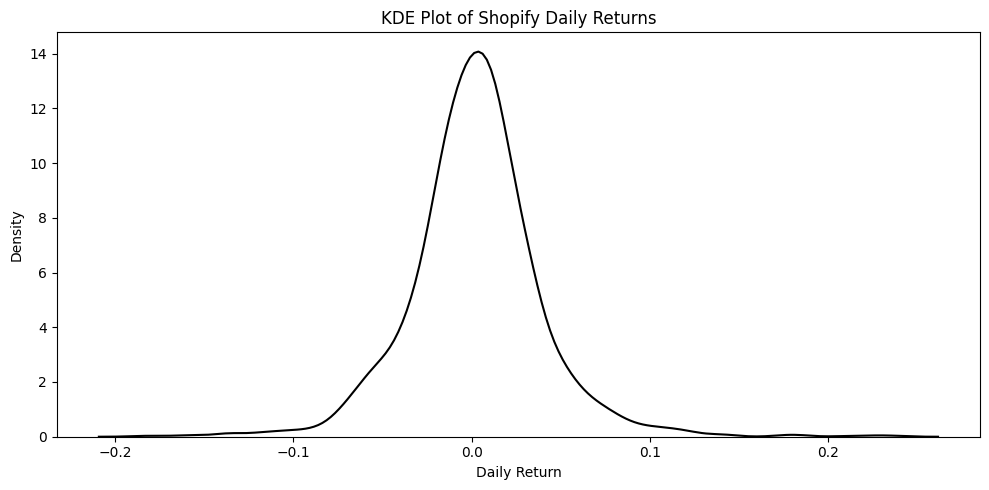

In [11]:
plt.figure(figsize=(10, 5))
sns.kdeplot(returns, color='black')
plt.title('KDE Plot of Shopify Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## 10. Check Return Statistics

In [12]:
mean_return = returns.mean()
std_return = returns.std()
variance_return = returns.var()

print('Mean daily return:', round(mean_return, 6))
print('Variance of daily returns:', round(variance_return, 6))
print('Standard deviation of daily returns:', round(std_return, 6))

Mean daily return: 0.002148
Variance of daily returns: 0.001378
Standard deviation of daily returns: 0.037122


## 11. 20-Day Rolling Volatility

In [13]:
df['rolling_volatility'] = df['daily_return'].rolling(window=20).std()

df[['date', 'rolling_volatility']].tail()

,date,rolling_volatility
2464,2025-03-10 00:00:00-04:00,0.035907
2465,2025-03-11 00:00:00-04:00,0.035251
2466,2025-03-12 00:00:00-04:00,0.035785
2467,2025-03-13 00:00:00-04:00,0.037396
2468,2025-03-14 00:00:00-04:00,0.036208


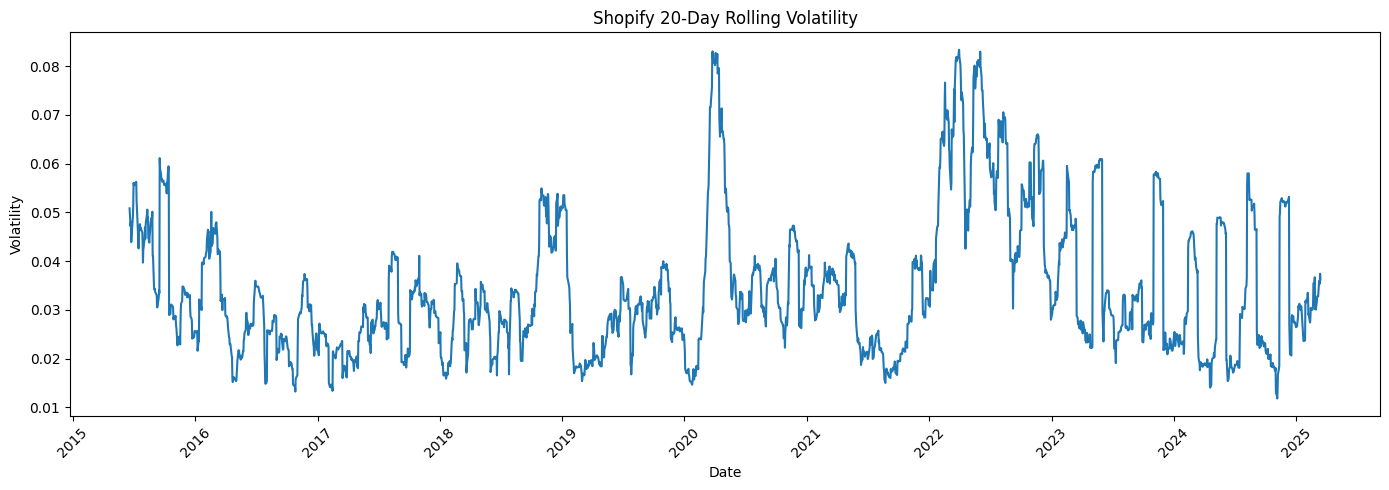

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['rolling_volatility'])
plt.title('Shopify 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Find High-Volatility Periods

In [15]:
volatility_limit = df['rolling_volatility'].quantile(0.95)

high_volatility = df[df['rolling_volatility'] >= volatility_limit][
    ['date', 'close', 'daily_return', 'rolling_volatility']
]

print('95th percentile volatility:', round(volatility_limit, 6))
high_volatility.head(10)

95th percentile volatility: 0.064451


,date,close,daily_return,rolling_volatility
1212,2020-03-16 00:00:00-04:00,32.229000,-0.175518,0.066224
1213,2020-03-17 00:00:00-04:00,35.508999,0.101772,0.071564
1214,2020-03-18 00:00:00-04:00,33.682999,-0.051424,0.071558
1215,2020-03-19 00:00:00-04:00,33.250000,-0.012855,0.071564
1216,2020-03-20 00:00:00-04:00,34.605999,0.040782,0.072855
1217,2020-03-23 00:00:00-04:00,37.539001,0.084754,0.075661
1218,2020-03-24 00:00:00-04:00,43.000000,0.145475,0.082603
1219,2020-03-25 00:00:00-04:00,44.660000,0.038605,0.083045
1220,2020-03-26 00:00:00-04:00,44.741001,0.001814,0.081382
1221,2020-03-27 00:00:00-04:00,42.161999,-0.057643,0.081511


## 13. Largest Daily Return Changes

In [16]:
largest_moves = df.loc[df['daily_return'].abs().nlargest(10).index,
                       ['date', 'close', 'daily_return']].sort_values('date')

largest_moves

,date,close,daily_return
82,2015-09-17 00:00:00-04:00,3.555000,0.229678
1212,2020-03-16 00:00:00-04:00,32.229000,-0.175518
1719,2022-03-18 00:00:00-04:00,78.000000,0.186528
1873,2022-10-27 00:00:00-04:00,34.099998,0.173434
1883,2022-11-10 00:00:00-05:00,36.509998,0.181553
2002,2023-05-04 00:00:00-04:00,57.299999,0.238383
2128,2023-11-02 00:00:00-04:00,59.700001,0.223611
2256,2024-05-08 00:00:00-04:00,62.730000,-0.185853
2318,2024-08-07 00:00:00-04:00,63.889999,0.178347
2386,2024-11-12 00:00:00-05:00,108.919998,0.210357


## 14. Simple Financial Summary Report

In [17]:
start_price = df['close'].iloc[0]
end_price = df['close'].iloc[-1]
price_change = end_price - start_price
price_change_percent = (end_price / start_price - 1) * 100

max_daily_return = returns.max() * 100
min_daily_return = returns.min() * 100

high_vol_start = high_volatility['date'].min()
high_vol_end = high_volatility['date'].max()

print('FINANCIAL SUMMARY')
print('------------------')
print(f'Data period: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Starting close price: ${start_price:.2f}')
print(f'Ending close price: ${end_price:.2f}')
print(f'Overall price change: ${price_change:.2f} ({price_change_percent:.2f}%)')
print(f'Mean daily return: {mean_return * 100:.3f}%')
print(f'Standard deviation of daily returns: {std_return * 100:.3f}%')
print(f'Largest positive daily return: {max_daily_return:.2f}%')
print(f'Largest negative daily return: {min_daily_return:.2f}%')
print(f'High-volatility observations begin around: {high_vol_start.date()}')
print(f'High-volatility observations end around: {high_vol_end.date()}')

FINANCIAL SUMMARY
------------------
Data period: 2015-05-21 to 2025-03-14
Starting close price: $2.57
Ending close price: $94.85
Overall price change: $92.28 (3593.54%)
Mean daily return: 0.215%
Standard deviation of daily returns: 3.712%
Largest positive daily return: 23.84%
Largest negative daily return: -18.59%
High-volatility observations begin around: 2020-03-16
High-volatility observations end around: 2022-11-23


## 15. Conclusion

In [18]:
print('The stock price changed over time with periods of stronger and weaker movement.')
print('The moving averages help us see the broader price trend.')
print('The daily return distribution shows how much the stock price usually changes in one trading day.')
print('The 20-day rolling volatility highlights periods when price movements became unusually large.')
print('A wider and less normal return distribution can indicate higher financial risk.')

The stock price changed over time with periods of stronger and weaker movement.
The moving averages help us see the broader price trend.
The daily return distribution shows how much the stock price usually changes in one trading day.
The 20-day rolling volatility highlights periods when price movements became unusually large.
A wider and less normal return distribution can indicate higher financial risk.
